# Figure 6 — AGA Pathogenesis: Cell Communication & Macrophage Subtypes

## Load libraries

In [1]:
library(Seurat)
library(ggplot2)
library(ggpubr)
library(dplyr)
library(stringr)
library(grid)
library(tibble)
library(parallel)
library(RColorBrewer)
library(patchwork)
library(future)
library(ComplexHeatmap)
library(clusterProfiler)
library(viridis)
library(tidyr)
library(ggrepel)
library(Signac)
library(CellChat)
library(reshape2)
library(gridExtra)
library(scales)
library(DESeq2)

Attaching SeuratObject


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


ComplexHeatmap version 2.14.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))




clusterProfiler v4.6.0  For help: https://yulab-smu.top/biomedical-knowledg

## Setup: directories, colors, theme, helper functions

In [2]:
DATA_DIR <- "data"
OUT_DIR  <- "output"
dir.create(OUT_DIR, showWarnings = FALSE)

# ---- Color & Theme ----
colorlist <- c("#FFFF00", "#1CE6FF", "#FF34FF", "#FF4A46", "#008941",
               "#006FA6", "#A30059", "#FFE4E1", "#0000A6", "#63FFAC",
               "#B79762", "#004D43", "#8FB0FF", "#997D87", "#5A0007",
               "#809693", "#1B4400", "#4FC601", "#3B5DFF", "#FF2F80",
               "#BA0900", "#6B7900", "#00C2A0", "#FFAA92", "#FF90C9",
               "#B903AA", "#DDEFFF", "#7B4F4B", "#A1C299", "#0AA6D8",
               "#00A087FF", "#4DBBD5FF", "#E64B35FF", "#3C5488FF", "#F38400",
               "#A1CAF1", "#C2B280", "#848482", "#E68FAC", "#0067A5",
               "#F99379", "#604E97", "#F6A600", "#B3446C", "#DCD300",
               "#882D17", "#8DB600", "#654522", "#E25822", "#2B3D26",
               "#191970", "#000080", "#6495ED", "#1E90FF", "#00BFFF",
               "#00FFFF", "#FF1493", "#FF00FF", "#A020F0", "#63B8FF",
               "#008B8B", "#54FF9F", "#00FF00", "#76EE00", "#FFF68F")

black_theme <- function() {
  theme(
    panel.grid = element_blank(),
    panel.background = element_rect(fill = NA),
    panel.border = element_rect(color = "white", linewidth = 0.5, fill = NA),
    plot.title = element_text(hjust = 0.5, size = 14, color = "white"),
    plot.background = element_rect(fill = 'black'),
    axis.line = element_line(color = "white", linewidth = 0),
    axis.text = element_text(color = "white", size = 12),
    axis.text.x = element_text(angle = 0, hjust = 0, vjust = 0),
    axis.title = element_text(color = "white", size = 14),
    axis.ticks = element_line(color = "white", linewidth = 0.5),
    legend.title = element_text(color = "white", size = 12),
    legend.text = element_text(color = "white", size = 12),
    legend.key = element_rect(fill = NA),
    legend.background = element_rect(fill = NA),
    legend.position = "right"
  )
}

# ---- Helper: DotPlot ----
dotplot_bw <- function(data, features, group.by, title,
                       viridis_option = "viridis", size_range = c(3, 8),
                       width = 3.5, height = 2.5, filename = NULL) {
  p <- DotPlot(data, features = rev(features), group.by = group.by) +
    scale_color_viridis(option = viridis_option) +
    scale_size_continuous(guide = guide_legend(order = 1), range = size_range) +
    guides(size = guide_legend(title = "Ratio (%)"),
           color = guide_colorbar(title = "Exp.")) +
    black_theme() + labs(x = "", y = "", title = title) +
    theme(axis.text.x = element_text(angle = 0, hjust = 0.5, vjust = 0.5))
  if (!is.null(filename)) ggsave(p, file = filename, width = width, height = height)
  p
}

## Load Seurat object & metadata

In [3]:
# ---- Load Seurat object ----
obj <- readRDS(file.path(DATA_DIR, "HF_RNA_postQC_rpca_241011.rds"))
meta <- readRDS(file.path(DATA_DIR, "HF_RNA_rpca_meta_240612.rds"))

meta$Age <- as.numeric(as.character(meta$Age))
meta$AgeGroup <- sapply(meta$Age, function(a) {
  if (is.na(a)) NA
  else if (3 <= a & a <= 17) "Juvenile"
  else if (18 <= a & a <= 39) "Prime age"
  else if (40 <= a & a <= 59) "Mid age"
  else "Old age"
})
meta$AgeGroup <- factor(meta$AgeGroup, levels = c("Juvenile", "Prime age", "Mid age", "Old age"), ordered = FALSE)
meta$sample <- ifelse(grepl("^H[BO]", meta$sample), "HO",
                     ifelse(meta$sample == "AB" | meta$sample == "AO", "AO", meta$sample))
meta$sample <- factor(meta$sample, levels = c('HO', 'AO', 'AF'))
obj@meta.data <- meta[colnames(obj),]

RCTD.color <- read.csv(file.path(DATA_DIR, "RCTD.color1_251210.csv"))
color1 <- RCTD.color$Color
names(color1) <- RCTD.color$abbreviation

RCTD.color2 <- read.delim(file.path(DATA_DIR, "RCTD.color_LastlEdition240612.txt"), header = TRUE, sep = "\t")
recoding <- setNames(RCTD.color2$abbreviation, RCTD.color2$order)

## Figure 6a — CellChat AGA Source Barplot

柱状图：展示 HO / AO / AF 三组中各细胞类型作为 source 的通讯概率。

数据准备见 `Figure6a_cellchat_prepare.ipynb`。

`summarise()` has grouped output by 'type'. You can override using the
`.groups` argument.
Adding missing grouping variables: `type`


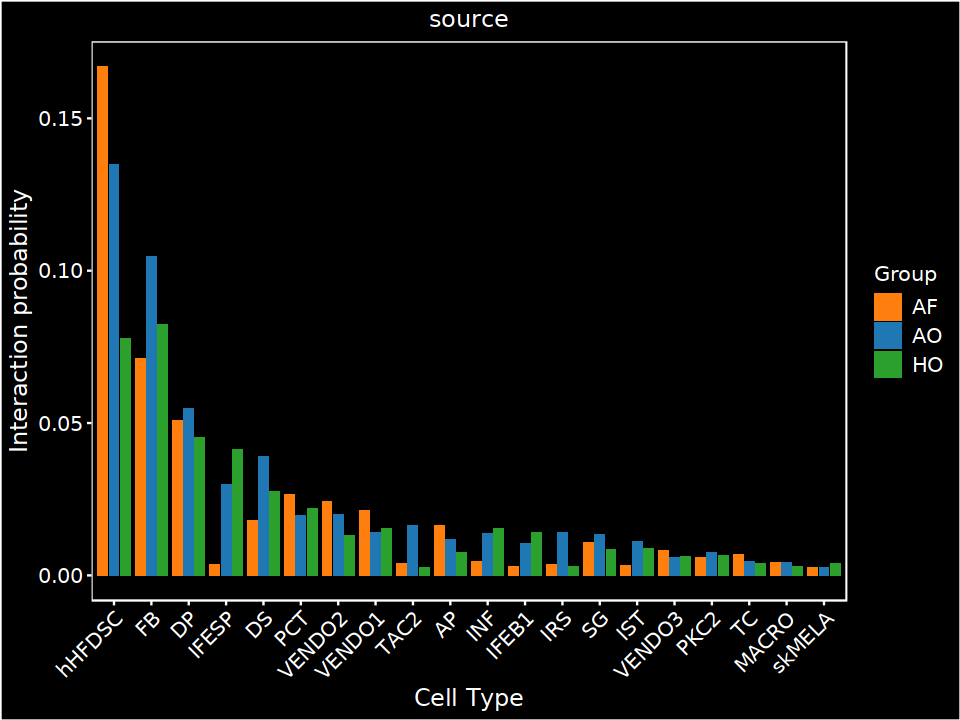

In [6]:
nep_6a <- read.csv(file.path(DATA_DIR, "Figure6a_cellchat_nep.csv"), row.names = 1, stringsAsFactors = FALSE)
nep_6a <- nep_6a %>%
  mutate(sample = recode(sample, "HB" = "HO", "AB" = "AO"))

data.nep_6a <- nep_6a %>%
  select(source, target, prob, sample)
data.nep_6a <- gather(data.nep_6a, key = "type", value = "celltype", source, target)
data.nep_6a$type <- paste(data.nep_6a$sample, data.nep_6a$type)
data.nep_6a <- data.nep_6a %>%
  group_by(type, celltype) %>%
  summarise(avg_prob = sum(prob))

data.nep_6a$celltype[data.nep_6a$celltype == "Unknown"] <- "Schwann"
data.nep_6a$celltype <- recode(data.nep_6a$celltype, !!!recoding)

data.sub_6a <- subset(data.nep_6a, type %in% c('AO source', 'AF source', 'HO source'))
data.count_6a <- data.sub_6a %>%
  select(celltype, avg_prob) %>%
  group_by(celltype) %>%
  arrange(avg_prob)
data.nep_6a <- subset(data.nep_6a, celltype %in% tail(unique(data.count_6a$celltype), 20))

source_6a <- subset(data.nep_6a, grepl("source", type))
source_6a <- source_6a %>%
  separate(type, into = c("group", "type"), sep = " ") %>%
  arrange(desc(avg_prob))

celltype_order_6a <- source_6a %>% pull(celltype) %>% unique()
source_6a$celltype <- factor(source_6a$celltype, levels = celltype_order_6a)
source_6a$group <- factor(source_6a$group, levels = c("AF", "AO", "HO"))

p_6a <- ggplot(source_6a, aes(x = celltype, y = avg_prob, fill = group)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.9), width = 0.8) +
  scale_fill_manual(values = c("AO" = "#1f77b4", "AF" = "#ff7f0e", "HO" = "#2ca02c")) +
  labs(title = "source", x = "Cell Type", y = "Interaction probability", fill = "Group") +
  black_theme() + 
  theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1))

ggsave(p_6a, file = file.path(OUT_DIR, "Figure6a_AGA_cellchat_source_barplot.pdf"), width = 8, height = 6)
options(repr.plot.width =8, repr.plot.height = 6)
p_6a

## Figure 6b — CellChat AGA Pathway RankNet

CellChat rankNet：比较 HO vs AF 的信号通路通讯概率。

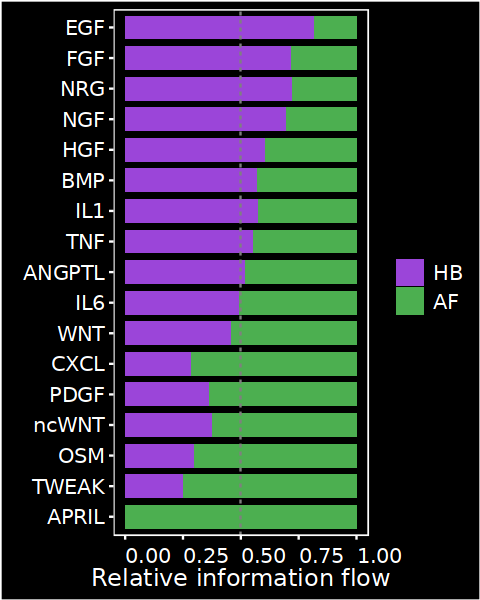

In [26]:
cellchat_6b <- readRDS(file.path(DATA_DIR, "Figure6b_cellchat.rds"))

pathway_6b <- c("EGF", "FGF", "NRG", "NGF", "HGF", "BMP", "IL1", "TNF",
                "ANGPTL", "IL6", "WNT", "CXCL", "PDGF", "ncWNT", "OSM",
                "TWEAK", "APRIL")
colors_6b <- c("#9b45d9", "#4CAF50")

p_6b <- rankNet(cellchat_6b, mode = "comparison", signaling = pathway_6b,
                comparison = c(1, 3), stacked = T, do.stat = TRUE, color.use = colors_6b) +
  black_theme()+
  theme(
    axis.text.y = element_text(size = 12, color = "white"),
    axis.text.x = element_text(size = 12, color = "white"),
    axis.title = element_text(size = 14, color = "white"),
    plot.title = element_text(hjust = 0.5, size = 14, color = "white"),
    panel.grid = element_blank(),
    legend.position = "right"
  )
ggsave(p_6b, file = file.path(OUT_DIR, "Figure6b_AGA_cellchat_pathway_barplot.pdf"), width = 4, height = 5)
options(repr.plot.width =4, repr.plot.height = 5)
p_6b

## Figure 6c — hHFDSC/aHFSC DotPlot (AGA ligand/receptor)

两组 DotPlot：展示 hHFDSC 配体和 aHFSC 受体在 HO/AO/AF 组中的表达。

Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


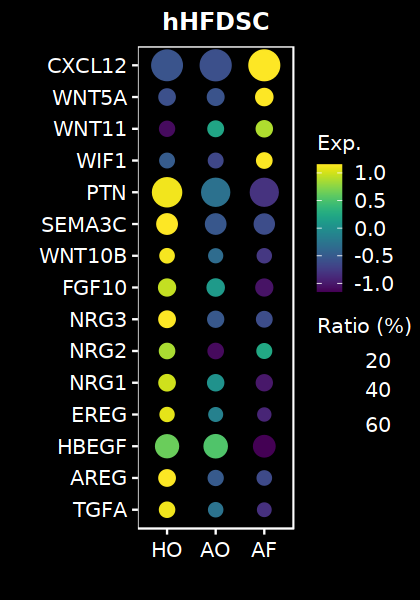

In [4]:
sub_6c_hHFDSC <- subset(obj, AgeGroup %in% c('Prime age', 'Mid age') & Abbreviation == 'hHFDSC')
sub_6c_aHFSC <- subset(obj, AgeGroup %in% c('Prime age', 'Mid age') & Abbreviation == 'aHFSC')
sub_6c_hHFDSC$sample <- factor(sub_6c_hHFDSC$sample, levels = c('HO', 'AO', 'AF'))
sub_6c_aHFSC$sample <- factor(sub_6c_aHFSC$sample, levels = c('HO', 'AO', 'AF'))

gene_ligand_6c <- rev(c("TGFA", "AREG", "HBEGF", "EREG", "NRG1", "NRG2", "NRG3",
                         "FGF10", "WNT10B", "SEMA3C", "PTN", "WIF1", "WNT11", "WNT5A", "CXCL12"))
gene_receptor_6c <- rev(c("EGFR", "NRP1", "NRP2", "PTPRZ1"))

DefaultAssay(sub_6c_hHFDSC) <- 'RNA'
p_6c_hHFDSC <- dotplot_bw(sub_6c_hHFDSC, gene_ligand_6c, 'sample', "hHFDSC",
                           width = 3.5, height = 2.5,
                           filename = file.path(OUT_DIR, "Figure6c_hHFDSC_ligand_DotPlot.pdf"))+coord_flip()
options(repr.plot.width =3.5, repr.plot.height = 5)
p_6c_hHFDSC

Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


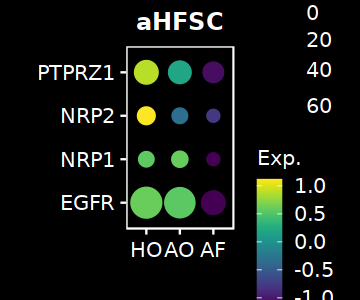

In [8]:
DefaultAssay(sub_6c_aHFSC) <- 'RNA'
p_6c_aHFSC <- dotplot_bw(sub_6c_aHFSC, gene_receptor_6c, 'sample', "aHFSC",
                          width = 3, height = 2.5,
                          filename = file.path(OUT_DIR, "Figure6c_aHFSC_receptor_DotPlot.pdf"))+coord_flip()
options(repr.plot.width =3, repr.plot.height = 2.5)
p_6c_aHFSC

## Figure 6e — Bulk RNA PCA (DSC-HFSC)

PCA 散点图：展示 bulk RNA-seq 样本的 PCA 聚类。

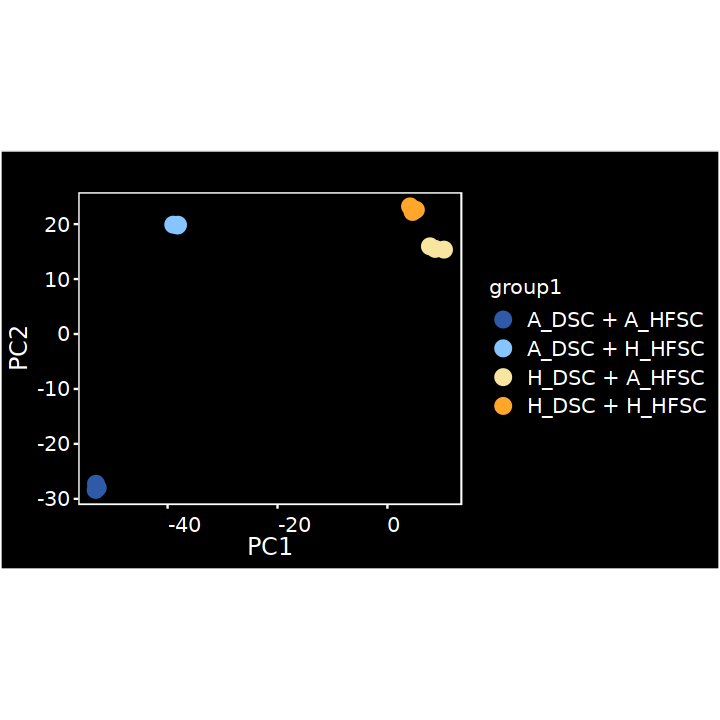

In [12]:
dds_6e <- readRDS(file.path(DATA_DIR, "Figure6e_deseq2.rds"))
dds_rlog <- rlog(dds_6e, blind=FALSE)
pca = plotPCA(dds_rlog, intgroup="group1", ntop=2000, returnData = T)

pca1_6e <- pca %>% filter(!group1 %in% c('A_HFSC', 'H_HFSC'))
p_6e <- ggplot(pca1_6e, aes(x = PC1, y = PC2, color = group1)) +
  geom_point(size = 4) +
  black_theme() +
  labs(title = "") +
  scale_color_manual(values = c('#2e5aa7', '#86c5ff', '#f8e6a0', '#ffa62b'))+coord_fixed()

ggsave(p_6e, file = file.path(OUT_DIR, "Figure6e_bulkRNA_DSC_HFSC_PCA.pdf"), width = 6, height = 6)
options(repr.plot.width =6, repr.plot.height = 6)

p_6e

## Figure 6i — MACRO/LGS/aHFSC DotPlot (AGA cytokine)

三组 DotPlot：展示 MACRO、LGS、aHFSC 中炎症因子及受体的表达。

Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


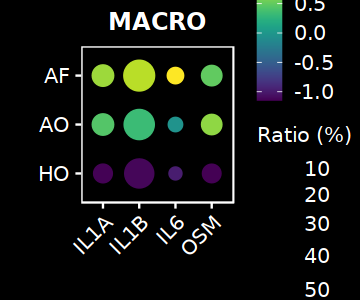

In [16]:
sub_6i_MACRO <- subset(obj, AgeGroup %in% c('Prime age', 'Mid age') & Abbreviation == 'MACRO')
sub_6i_LGS <- subset(obj, AgeGroup %in% c('Prime age', 'Mid age') & Abbreviation == 'LGS')
sub_6i_aHFSC <- subset(obj, AgeGroup %in% c('Prime age', 'Mid age') & Abbreviation == 'aHFSC')
sub_6i_MACRO$sample <- factor(sub_6i_MACRO$sample, levels = c('HO', 'AO', 'AF'))
sub_6i_LGS$sample <- factor(sub_6i_LGS$sample, levels = c('HO', 'AO', 'AF'))
sub_6i_aHFSC$sample <- factor(sub_6i_aHFSC$sample, levels = c('HO', 'AO', 'AF'))

gene_MACRO_6i <- rev(c("IL1A", "IL1B", "IL6", "OSM"))
gene_LGS_6i <- c("TNF")
gene_aHFSC_6i <- rev(c("IL1R1", "IL6R", "OSMR", "TNFRSF1A", "TNFRSF1B"))

DefaultAssay(sub_6i_MACRO) <- 'RNA'
p_6i_MACRO <- dotplot_bw(sub_6i_MACRO, gene_MACRO_6i, 'sample', "MACRO",
                          width = 3, height = 2.5,
                          filename = file.path(OUT_DIR, "Figure6i_IL1_etal_MACRO_DotPlot.pdf"))+ 
                          theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1))

options(repr.plot.width =3, repr.plot.height = 2.5)
p_6i_MACRO

Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


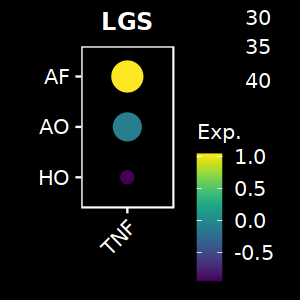

In [19]:
DefaultAssay(sub_6i_LGS) <- 'RNA'
p_6i_LGS <- dotplot_bw(sub_6i_LGS, gene_LGS_6i, 'sample', "LGS",
                        width = 2.5, height = 2.5,
                        filename = file.path(OUT_DIR, "Figure6i_TNF_LGS_DotPlot.pdf"))+
                        theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1))
options(repr.plot.width =2.5, repr.plot.height = 2.5)
p_6i_LGS

Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


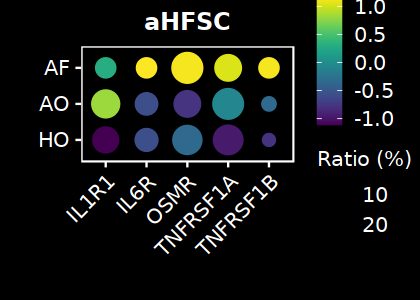

In [21]:
DefaultAssay(sub_6i_aHFSC) <- 'RNA'
p_6i_aHFSC <- dotplot_bw(sub_6i_aHFSC, gene_aHFSC_6i, 'sample', "aHFSC",
                          width = 3.5, height = 2.5,
                          filename = file.path(OUT_DIR, "Figure6i_IL1R1_etal_aHFSC_DotPlot.pdf"))+
                          theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1))
options(repr.plot.width =3.5, repr.plot.height = 2.5)
p_6i_aHFSC

## Figure 6j — MACRO Subclustering

对 MACRO 细胞进行亚群整合聚类 (rpca integration + UMAP)。

In [ ]:
sub5 <- subset(obj, AgeGroup %in% c('Prime age', 'Mid age') & Abbreviation == 'MACRO')
sub5$sample <- factor(sub5$sample, levels = c('HO', 'AO', 'AF'))

DefaultAssay(sub5) <- "RNA"
sub5_list <- SplitObject(sub5, split.by = "sample")
sub5_list <- lapply(sub5_list, function(x) {
  x <- NormalizeData(x)
  x <- FindVariableFeatures(x, selection.method = "vst", nfeatures = 500)
})

features_6j <- SelectIntegrationFeatures(object.list = sub5_list)
sub5_list <- lapply(sub5_list, function(x) {
  x <- ScaleData(x, features = features_6j, verbose = FALSE)
  x <- RunPCA(x, features = features_6j, verbose = FALSE)
})

sub5_anchors <- FindIntegrationAnchors(object.list = sub5_list, anchor.features = features_6j, reduction = "rpca")
sub5_integrated <- IntegrateData(anchorset = sub5_anchors)

sub5_integrated <- sub5_integrated %>%
  FindVariableFeatures(selection.method = "vst", nfeatures = 500) %>%
  ScaleData() %>%
  RunPCA(npcs = 20, verbose = FALSE) %>%
  FindNeighbors(dims = 1:20) %>%
  FindClusters(resolution = c(0.2, 0.5)) %>%
  RunUMAP(dims = 1:20)

sub5_integrated_1 <- subset(sub5_integrated, integrated_snn_res.0.2 %in% c(4, 6), invert = TRUE)
sub5_integrated_1 <- RunUMAP(sub5_integrated_1, dims = 1:20)
sub5_integrated_1@meta.data$subMACRO <- case_when(
  sub5_integrated_1@meta.data$integrated_snn_res.0.2 %in% c(0, 1, 3, 5) ~ "TREM2-MACRO",
  sub5_integrated_1@meta.data$integrated_snn_res.0.2 == 2 ~ "TREM2+MACRO",
  TRUE ~ "Other"
)
saveRDS(sub5_integrated_1, file.path(OUT_DIR, "Figure6j_MACRO_subIntegrated.rds"))

In [26]:
getwd()

[1] "/data/work/002.Rework_lei/20260819_Figure346_Code/Figure6"

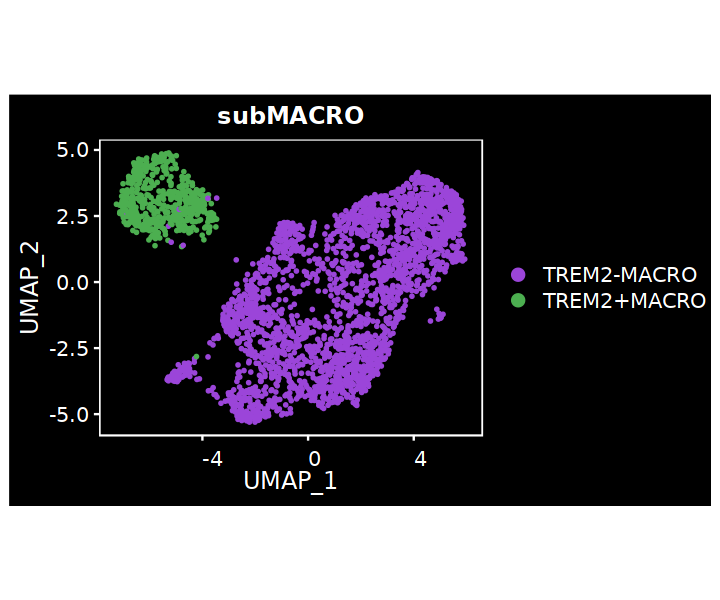

In [29]:
sub5_integrated_1 <- readRDS(file.path(DATA_DIR, "Figure6j_MACRO_subIntegrated.rds"))
colors_6j <- c("#9b45d9", "#4CAF50")
p_6j <- DimPlot(sub5_integrated_1, reduction = "umap", group.by = "subMACRO",
                 raster = FALSE, cols = colors_6j, label = F) +
  black_theme() + theme(legend.position = "right")+ coord_fixed()

ggsave(p_6j, file = file.path(OUT_DIR, "Figure6j_MACRO_subIntegrated_UMAP.pdf"), width = 6, height = 5)
options(repr.plot.width =6, repr.plot.height = 5)
p_6j

## Figure 6k — MACRO Subtype Marker DotPlot

DotPlot：展示 MACRO 亚群 marker 基因 (OSM / TREM2) 表达。

Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


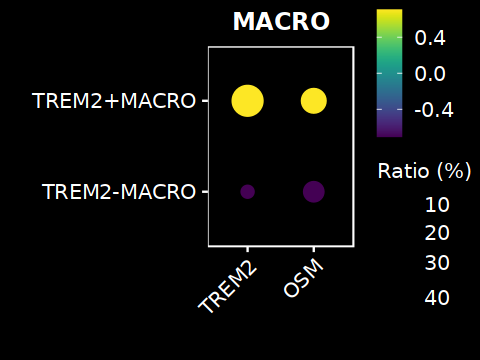

In [34]:
gene_6k <- c('OSM', 'TREM2')
DefaultAssay(sub5_integrated_1) <- 'RNA'
p_6k <- dotplot_bw(sub5_integrated_1, gene_6k, 'subMACRO', "MACRO",
                    width = 4, height = 3,
                    filename = file.path(OUT_DIR, "Figure6k_MACRO_sub_marker_DotPlot.pdf"))+
                     theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1))
options(repr.plot.width =4, repr.plot.height = 3)
p_6k

## Figure 6l — MACRO Subtype Proportion Barplot

堆叠比例柱状图：展示 MACRO 亚群在 HO / AO / AF 中的比例。

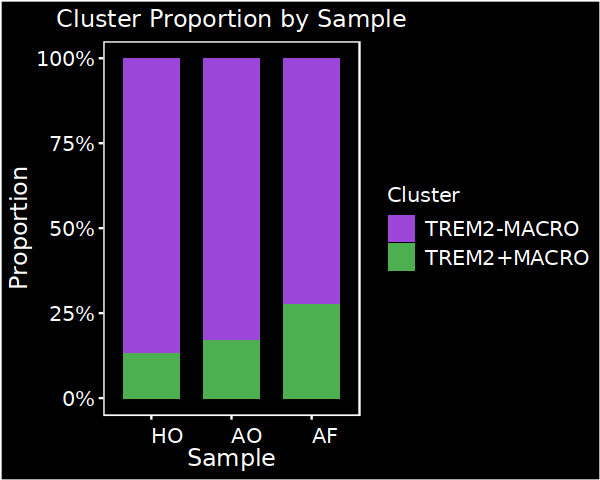

In [35]:
sub5_integrated_1$sample <- factor(sub5_integrated_1$sample, levels = c('HO', 'AO', 'AF'))

cluster_stats_6l <- sub5_integrated_1@meta.data %>%
  select(sample, cluster = subMACRO) %>%
  mutate(cluster = as.factor(cluster)) %>%
  group_by(sample, cluster) %>%
  summarise(cell_count = n(), .groups = "drop") %>%
  group_by(sample) %>%
  mutate(prop = cell_count / sum(cell_count)) %>%
  ungroup()

p_6l <- ggplot(cluster_stats_6l, aes(x = sample, y = prop, fill = cluster)) +
  geom_col(width = 0.7) +
  scale_y_continuous(labels = percent_format(accuracy = 1)) +
  scale_fill_manual(values = colors_6j) +
  labs(title = "Cluster Proportion by Sample", x = "Sample", y = "Proportion", fill = "Cluster") +
  black_theme()

ggsave(p_6l, file = file.path(OUT_DIR, "Figure6l_MACRO_sub_proportion_barplot.pdf"), width = 5, height = 4)
options(repr.plot.width =5, repr.plot.height = 4)
p_6l

## Figure 6m — TREM2+MACRO Proportion Line Plot

折线图：展示 TREM2+MACRO 比例在 HO / AO / AF 组中的变化趋势。

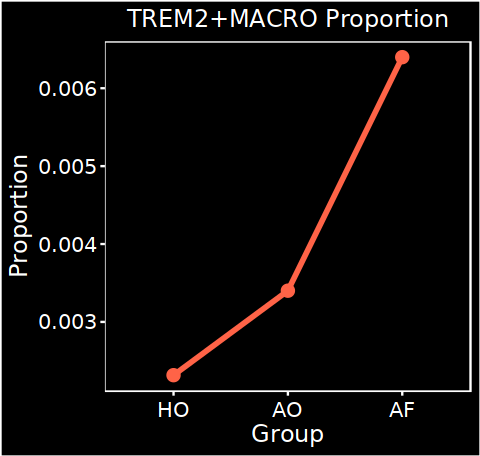

In [36]:
data_6m <- readRDS(file.path(DATA_DIR, "Figure6m_macro_sub.rds"))
match_idx <- match(rownames(meta), rownames(data_6m@meta.data))
meta$subMACRO <- data_6m@meta.data$subMACRO[match_idx]
meta$subMACRO <- as.character(meta$subMACRO)
meta$Abbreviation <- as.character(meta$Abbreviation)
meta$subMACRO[is.na(meta$subMACRO)] <- meta$Abbreviation[is.na(meta$subMACRO)]

sub_6m <- subset(meta, AgeGroup %in% c('Prime age', 'Mid age'))
cluster_stats_6m <- sub_6m %>%
  dplyr::select(group = sample, cluster = subMACRO) %>%
  dplyr::mutate(cluster = as.factor(cluster)) %>%
  dplyr::group_by(group, cluster) %>%
  dplyr::summarise(cell_count = n(), .groups = "drop") %>%
  dplyr::group_by(group) %>%
  dplyr::mutate(prop = cell_count / sum(cell_count)) %>%
  dplyr::ungroup()

trem2_data_6m <- cluster_stats_6m %>%
  filter(cluster == "TREM2+MACRO") %>%
  mutate(group = factor(group, levels = unique(group)))

p_6m <- ggplot(trem2_data_6m, aes(x = group, y = prop, group = 1)) +
  geom_line(color = "#FF6347", linewidth = 1.2) +
  geom_point(color = "#FF6347", size = 3) +
  labs(title = "TREM2+MACRO Proportion", x = "Group", y = "Proportion") +
  black_theme() +
  theme(axis.text.x = element_text(size = 12, angle = 0, hjust = 0.5, vjust = 0.5, color = "white"))

ggsave(p_6m, file = file.path(OUT_DIR, "Figure6m_TREM2_MACRO_proportion_lineplot.pdf"), width = 4, height = 3.8)
options(repr.plot.width =4, repr.plot.height = 3.8)

p_6m